Step 1 - Import Library

In [1]:
import requests
import base64
import json
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image
from tqdm import tqdm

Step 2 - Load dan Display Image

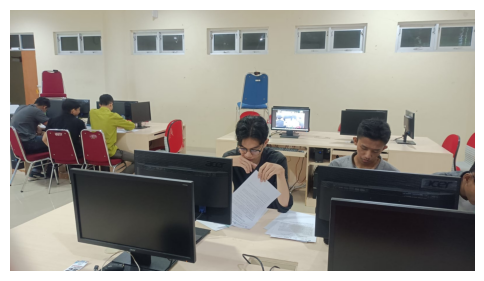

In [4]:
IMG_PATH="../img/sample5.jpeg"
img = Image.open(IMG_PATH)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.show()

Step 3 - Encode Image

In [5]:
def image_to_base64(image_path):
    with open(image_path, "rb") as f:
        encoded=base64.b64encode(f.read())
    return encoded.decode()

Step 4 - Function Qwen Vision

In [6]:
def ask_qwen_vision(image_path, prompt, model="qwen3.5:4b"):
    image_b64 = image_to_base64(image_path)
    payload={
        "model": model,
        "prompt": prompt,
        "images": [image_b64],
        "stream": False,
        "think": False,
    }
    response=requests.post(
        "http://localhost:11434/api/generate",
        json=payload
    )
    return response.json()["response"]

Step 5 - Experiment Caption

In [8]:
prompt="""Deskripsikan Gambar ini."""

result=ask_qwen_vision(IMG_PATH, prompt)
print(result)

**Deskripsi Gambar:**

Gambar ini menampilkan suasana **kelas komputer atau ruang belajar** di sekolah, mungkin saat ujian tertulis di depan layar komputernya, namun fokus mereka adalah pada dokumen kertas yang dibaca dan dikerjakan secara manual — kemungkinan uji tulis (essay) dalam bahasa Inggris. Ruangan terasa tenang dan fokus, dengan pencahayaan cukup terang dari lampu atap serta cahaya alami melalui jendela-jendela kecil berbentuk persegi panjang di dinding berwarna krem.

Di bagian depan gambar terlihat meja komputer dengan monitor Acer aktif; seorang pelajar berambut hitam pendek memakai kacamata, duduk bersila atau menekuk lututnya, sedang memegang dan membaca dokumen tulisan tangan yang tebal — mungkin soal ujian. Di sebelah kanannya, satu lagi pelajar pria tampak serius memperhatikan layar komputernya, sementara di sudut kanan bingkai gambar terlihat sebagian kepala seseorang lain juga fokus pada perangkatnya.

Di latar belakang, terdapat tiga orang siswa lainnya:  
- Seoran

Step 6 - Scene Understanding

In [9]:
prompt = """
Analisis gambar.
Hasil:
1 objek
2 lingkungan
3 aktivitas
4 detail penting
"""

result=ask_qwen_vision(IMG_PATH, prompt)
print(result)

Berikut adalah analisis mendalam mengenai isi dari gambar tersebut:

**Gambar ini menampilkan adegan di dalam ruang komputer (komputer lab) yang didominasi oleh siswa-siswa yang sedang mengerjakan tugas atau ujian secara individu.** Suasana tampak fokus dan serius. Berikut rinciannya:

### 1. Objek Utama
*   **Seksioner Komputer:** Terlihat banyak unit meja kerja standar dengan monitor Acer, keyboard, mouse, serta tower komputer di bawah meja. Beberapa laptop juga terlihat terpasang pada stand yang berdiri terpisah dari meja utama.
*   **Kursi dan Meja:** Kursi berwarna merah (dengan logo "UNIV") biru, dan putih dominan digunakan oleh para siswa. Mejanya berbentuk L dengan permukaan kayu atau laminate ringan, dirancang untuk menghemat ruang sekaligus memaksimalkan penggunaan komputer.

### 2. Lingkungan / Suasana
Ruang ini memiliki dinding yang bersih serta pencahayaan buatan cukup merata tanpa kesan dramatis. Terdapat jendela-jendela kecil di bagian atas tembok sebagai ventilasi tamba

Step 7 - Reasoning

In [10]:
prompt = """
Perhatikan dengan saksama.
Jelaskan:
1. apa yang terjadi sebelumnya
2. apa yang mungkin terjadi selanjutnya
3. mengapa
"""

print(ask_qwen_vision(IMG_PATH, prompt))

Berdasarkan gambar, kita dapat melihat sebuah ruang komputasi atau laboratorium komputer di mana beberapa orang sedang menggunakan komputer dan membaca dokumen — kemungkinan tugas akademik, ujian, atau proyek kelompok. Ada juga kursi-kursi kosong (biru dan merah) yang menunjukkan bahwa ruangan ini mungkin baru dibuka atau sebagian sudah selesai digunakan.

Mari kita analisis ketiga poin tersebut:

---

### 1. **Apa yang terjadi sebelumnya?**

Sebelum saat ini dalam gambar, kemungkinan besar telah terjadi proses persiapan untuk aktivitas akademik atau teknis di ruang komputer ini. Beberapa petunjuk mendukung hal itu:

- Ada siswa/siswa yang sedang menulis/menyalin sesuatu dari layar ke kertas (misalnya di kiri tengah).
- Beberapa meja masih kosong dengan kursi diletakkan tegak — bisa jadi baru saja dibersihkan setelah sebelumnya ada kelompok lain, atau justru sebelum kegiatan dimulai.
- Dokumen tercetak tersedia di atas meja, menunjukkan bahwa materi telah disiapkan secara offline mungk

Step 8 - Ask Question About Image

In [7]:
# question = input("Ask about the image: ")
question = "berapa jumlah orang?"
prompt = f"""Answer: {question}"""

print(ask_qwen_vision(IMG_PATH, prompt))

Berdasarkan gambar, terdapat **6 orang** yang terlihat jelas duduk dan bekerja di komputer atau membaca dokumen.

Berikut adalah rincian mereka berdasarkan posisi dalam ruangan:

1.  Seorang pria berpakaian abu-abu (kiri belakang) — sedang membungkuk ke depan meja.
2.  Sebuah wanita mengenakan baju hitam dengan topi — duduk bersebelah dengannya.
3.  Pria yang memakai kemeja hijau cerah — menghadap komputer.
4.  Laki-laki di tengah yang memegang kertas dan memakai kacamata — fokus pada dokumen tersebut.
5.  Seorang pria muda yang berada di sisi kanan dari laki-laki dengan kacamata, sedang menatap layar komputernya.
6.  Satu orang (hanya terlihat sebagian wajahnya) di sebelah kanan paling depan, dekat meja Acer.

Jumlah total adalah **orang**, yaitu:


Step 9 - Structured Output

In [8]:
prompt="""
Return HANYA JSON.
{
  "caption":"",
  "objects":[],
  "environment":"",
  "activity":""
}
"""

output=ask_qwen_vision(IMG_PATH, prompt)
print(output)

```json
{
"caption": "Several students are working in a computer lab, focusing on papers and screens at their desks.",
"objects": [
    "computer monitor",
    "keyboard",
    "desk",
    "chair",
    "paper",
    "students",
    "window",
    "wall",
    "ceiling light"
],
"environment": "Computer lab or classroom with multiple computer stations and windows along the wall.",
"activity": "Students reading documents and looking at their computers, likely studying or completing an assignment."
}
```


Step 10 - Save Result

In [10]:
results = []
results.append({
  "image": IMG_PATH,
  "output": output
})

df = pd.DataFrame(results)
df.to_csv("../output/results.csv", index=False)
df.head()

,image,output
0,../img/sample5.jpeg,"```json\n{\n""caption"": ""Several students are w..."
